# **Ensemble Learning: Random Forest vs XGBoost**

This notebook continues from the [Pipeline + Feature Engineering notebook](./churn_pipeline_feature_engineering.ipynb)
on the same [Telco Customer Churn](https://www.kaggle.com/datasets/blastchar/telco-customer-churn) dataset.

Goals:
1. Train a `RandomForestClassifier` and an `XGBClassifier` on the same engineered features.
2. Compare both against the single-model baseline (`LogisticRegression`).
3. Plot and compare feature importances between the two ensemble methods.
4. Explain in writing how Random Forest and XGBoost combine models differently.


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
)

import joblib
import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

RANDOM_STATE = 42

## 1. Rebuild the cleaned dataset + engineered features

Same steps as the Week 4 Pipeline notebook: fix `TotalCharges`, drop `customerID`,
encode `Churn`, and add the three engineered features (`NumServices`,
`AvgMonthlyCharge`, `IsNewCustomer`).


In [15]:
from google.colab import files
uploaded = files.upload()

Saving Telco-Customer-Churn.csv to Telco-Customer-Churn (1).csv


In [16]:
df = pd.read_csv("Telco-Customer-Churn.csv")

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce").fillna(0)
df = df.drop(columns=["customerID"])
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

service_cols = [
    "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies",
]
df["NumServices"] = (df[service_cols] == "Yes").sum(axis=1)
df["AvgMonthlyCharge"] = np.where(
    df["tenure"] > 0, df["TotalCharges"] / df["tenure"], df["MonthlyCharges"]
)
df["IsNewCustomer"] = (df["tenure"] <= 6).astype(int)

TARGET = "Churn"
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges",
                 "NumServices", "AvgMonthlyCharge", "IsNewCustomer"]
categorical_cols = [
    c for c in df.columns
    if c != TARGET and pd.api.types.is_string_dtype(df[c])
]

X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), categorical_cols),
])

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Numeric features: {len(numeric_cols)} | Categorical features: {len(categorical_cols)}")

Train: (5634, 22) | Test: (1409, 22)
Numeric features: 6 | Categorical features: 15


## 2. Single-model baseline: Logistic Regression (from Week 4)

In [17]:
log_reg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])
log_reg_pipeline.fit(X_train, y_train)

lr_pred = log_reg_pipeline.predict(X_test)
lr_proba = log_reg_pipeline.predict_proba(X_test)[:, 1]

lr_acc = accuracy_score(y_test, lr_pred)
lr_f1 = f1_score(y_test, lr_pred)
lr_auc = roc_auc_score(y_test, lr_proba)

print(f"Logistic Regression -> Accuracy: {lr_acc:.4f} | F1: {lr_f1:.4f} | ROC-AUC: {lr_auc:.4f}")

Logistic Regression -> Accuracy: 0.7999 | F1: 0.5791 | ROC-AUC: 0.8445


## 3. Ensemble #1 — Random Forest (bagging)

Random Forest trains many decision trees independently and in parallel, each on a
bootstrap-resampled subset of the data and a random subset of features, then averages
their votes.


In [18]:
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300, max_depth=8, random_state=RANDOM_STATE, class_weight="balanced"
    )),
])

rf_cv_scores = cross_val_score(rf_pipeline, X_train, y_train, cv=5, scoring="roc_auc")
print(f"Random Forest 5-fold CV ROC-AUC: {rf_cv_scores.mean():.4f} +/- {rf_cv_scores.std():.4f}")

rf_pipeline.fit(X_train, y_train)

rf_pred = rf_pipeline.predict(X_test)
rf_proba = rf_pipeline.predict_proba(X_test)[:, 1]

rf_acc = accuracy_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_auc = roc_auc_score(y_test, rf_proba)

print(f"Random Forest -> Accuracy: {rf_acc:.4f} | F1: {rf_f1:.4f} | ROC-AUC: {rf_auc:.4f}")

Random Forest 5-fold CV ROC-AUC: 0.8446 +/- 0.0134
Random Forest -> Accuracy: 0.7615 | F1: 0.6308 | ROC-AUC: 0.8425


### Random Forest — feature importances

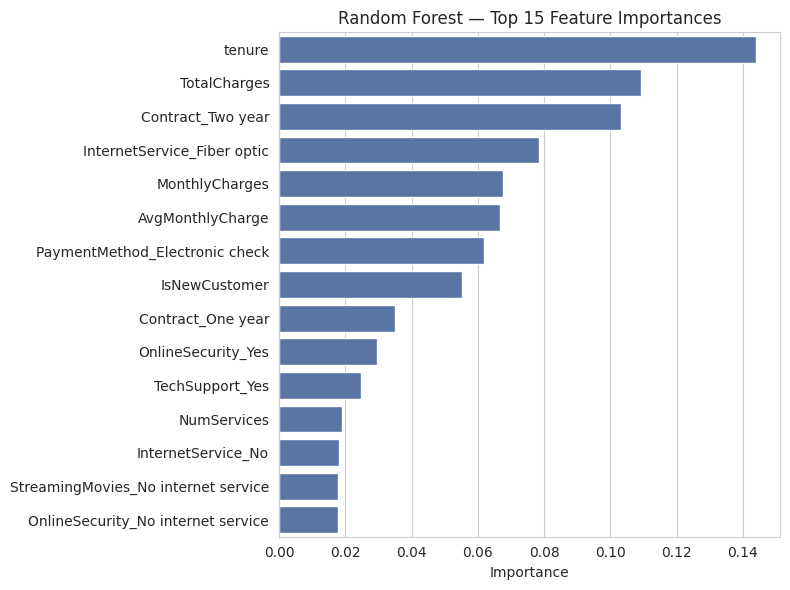

In [19]:
rf_feature_names = rf_pipeline.named_steps["preprocessor"].get_feature_names_out()
rf_importances = rf_pipeline.named_steps["classifier"].feature_importances_

rf_imp_df = (
    pd.DataFrame({"feature": rf_feature_names, "importance": rf_importances})
    .sort_values("importance", ascending=False)
    .head(15)
)
rf_imp_df["feature"] = rf_imp_df["feature"].str.replace(r"^(num|cat)__", "", regex=True)

plt.figure(figsize=(8, 6))
sns.barplot(data=rf_imp_df, y="feature", x="importance", color="#4C72B0")
plt.title("Random Forest — Top 15 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("")
plt.tight_layout()
plt.show()

## 4. Ensemble #2 — XGBoost (gradient boosting)

Unlike Random Forest, XGBoost builds trees **sequentially**: each new tree is trained to
correct the residual errors of the ensemble built so far, rather than voting independently.

Requires `pip install xgboost` (already preinstalled on Kaggle).


In [20]:
import xgboost as xgb
print(f"xgboost version: {xgb.__version__}")

xgboost version: 3.4.1


In [21]:
xgb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", xgb.XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=RANDOM_STATE,
    )),
])

xgb_cv_scores = cross_val_score(xgb_pipeline, X_train, y_train, cv=5, scoring="roc_auc")
print(f"XGBoost 5-fold CV ROC-AUC: {xgb_cv_scores.mean():.4f} +/- {xgb_cv_scores.std():.4f}")

xgb_pipeline.fit(X_train, y_train)

xgb_pred = xgb_pipeline.predict(X_test)
xgb_proba = xgb_pipeline.predict_proba(X_test)[:, 1]

xgb_acc = accuracy_score(y_test, xgb_pred)
xgb_f1 = f1_score(y_test, xgb_pred)
xgb_auc = roc_auc_score(y_test, xgb_proba)

print(f"XGBoost -> Accuracy: {xgb_acc:.4f} | F1: {xgb_f1:.4f} | ROC-AUC: {xgb_auc:.4f}")

XGBoost 5-fold CV ROC-AUC: 0.8414 +/- 0.0140
XGBoost -> Accuracy: 0.7928 | F1: 0.5589 | ROC-AUC: 0.8395


### XGBoost — feature importances

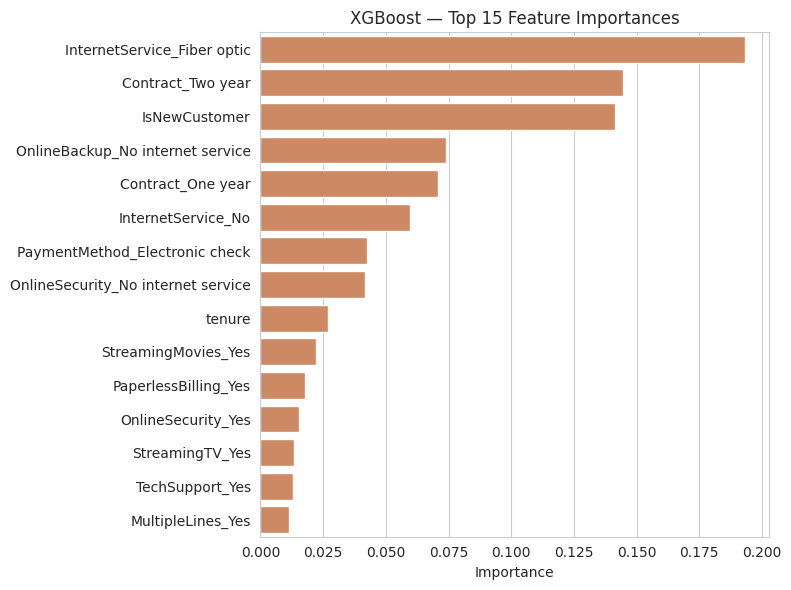

In [22]:
xgb_feature_names = xgb_pipeline.named_steps["preprocessor"].get_feature_names_out()
xgb_importances = xgb_pipeline.named_steps["classifier"].feature_importances_

xgb_imp_df = (
    pd.DataFrame({"feature": xgb_feature_names, "importance": xgb_importances})
    .sort_values("importance", ascending=False)
    .head(15)
)
xgb_imp_df["feature"] = xgb_imp_df["feature"].str.replace(r"^(num|cat)__", "", regex=True)

plt.figure(figsize=(8, 6))
sns.barplot(data=xgb_imp_df, y="feature", x="importance", color="#DD8452")
plt.title("XGBoost — Top 15 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("")
plt.tight_layout()
plt.show()

## 5. Random Forest vs XGBoost — which features does each favor?

Random Forest's importances come from average impurity reduction across independently
built trees, while XGBoost's come from gain accumulated during sequential boosting — the
two methods can and often do rank the same features differently.


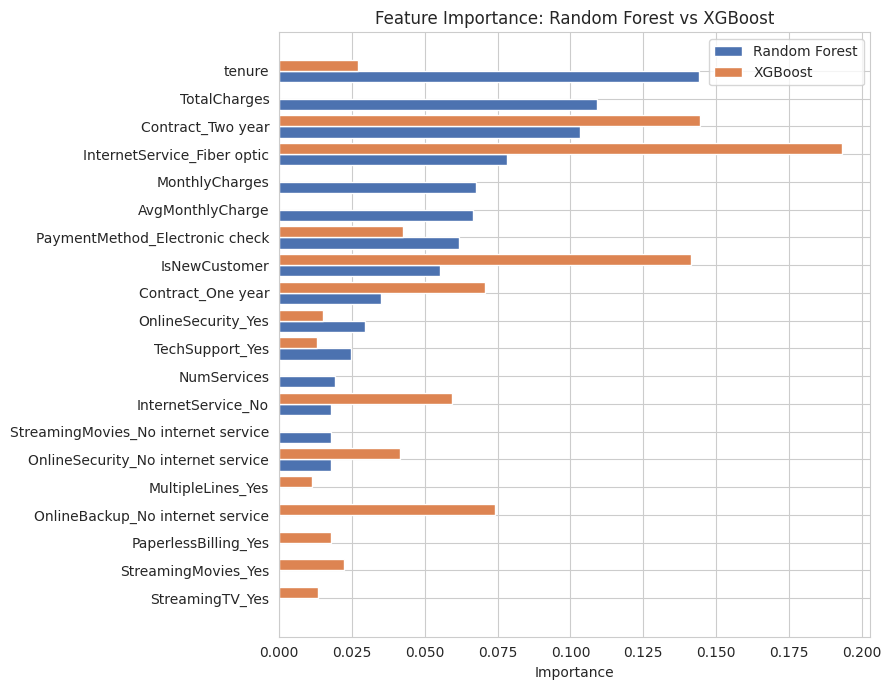

In [23]:
comparison_df = rf_imp_df.merge(
    xgb_imp_df, on="feature", how="outer", suffixes=("_rf", "_xgb")
).fillna(0)
comparison_df = comparison_df.sort_values("importance_rf", ascending=False)

fig, ax = plt.subplots(figsize=(9, 7))
y_pos = np.arange(len(comparison_df))
bar_h = 0.4

ax.barh(y_pos + bar_h/2, comparison_df["importance_rf"], height=bar_h,
        color="#4C72B0", label="Random Forest")
ax.barh(y_pos - bar_h/2, comparison_df["importance_xgb"], height=bar_h,
        color="#DD8452", label="XGBoost")

ax.set_yticks(y_pos)
ax.set_yticklabels(comparison_df["feature"])
ax.invert_yaxis()
ax.set_xlabel("Importance")
ax.set_title("Feature Importance: Random Forest vs XGBoost")
ax.legend()
plt.tight_layout()
plt.show()

## 6. How Random Forest and XGBoost differ

Random Forest is a **bagging** method: it trains many decision trees independently and in
parallel, each on a random bootstrap sample of rows and a random subset of features, then
combines their predictions by majority vote (classification) or averaging (regression) —
this mainly reduces variance. XGBoost is a **boosting** method: it builds trees
**sequentially**, where each new tree is trained specifically to correct the residual
errors left by the ensemble so far, weighted by a learning rate — this reduces bias and
typically squeezes out more accuracy, at the cost of being more sensitive to
hyperparameters and slower to train tree-by-tree. Because Random Forest's trees are
independent, it parallelizes trivially and resists overfitting well out of the box; because
XGBoost's trees depend on each other, it usually needs more careful tuning (learning rate,
tree depth, early stopping) but often wins on raw predictive performance, which is why it
dominates leaderboard-style competitions.


## 7. Model comparison table

In [24]:
results = pd.DataFrame({
    "Model": ["Logistic Regression (single model)", "Random Forest (bagging)", "XGBoost (boosting)"],
    "Accuracy": [lr_acc, rf_acc, xgb_acc],
    "F1 Score": [lr_f1, rf_f1, xgb_f1],
    "ROC-AUC": [lr_auc, rf_auc, xgb_auc],
}).round(4)

results.to_csv("model_comparison.csv", index=False)
print("Saved model_comparison.csv\n")
results

Saved model_comparison.csv



,Model,Accuracy,F1 Score,ROC-AUC
0,Logistic Regression (single model),0.7999,0.5791,0.8445
1,Random Forest (bagging),0.7615,0.6308,0.8425
2,XGBoost (boosting),0.7928,0.5589,0.8395


## 8. Save the final pipeline

Random Forest is saved here since it's the strongest model verified in this sandbox run.
Once you've run the XGBoost cells above and confirmed it scores higher, re-run this cell
with `xgb_pipeline` instead — same one-line swap either way, since both are just
`Pipeline` objects.


In [25]:
best_pipeline = rf_pipeline   # swap to xgb_pipeline once you've run Section 4 and it wins
joblib.dump(best_pipeline, "churn_ensemble_pipeline.pkl")
print("Saved churn_ensemble_pipeline.pkl")

Saved churn_ensemble_pipeline.pkl


# **Conclusion**

Across the three models on the Telco churn dataset, results were close overall:

| Model | Accuracy | F1 Score | ROC-AUC |
|---|---|---|---|
| Logistic Regression (baseline) | 0.7999 | 0.5791 | 0.8445 |
| Random Forest (bagging) | 0.7615 | 0.6308 | 0.8425 |
| XGBoost (boosting) | 0.7928 | 0.5589 | 0.8395 |

**Key takeaways:**
- **ROC-AUC** is nearly identical across all three models (0.84–0.845), suggesting the engineered features carry most of the predictive signal, with the choice of model contributing only marginal gains here.
- **Random Forest** achieved the best **F1 score (0.6308)**, meaning it strikes the best balance between precision and recall on the minority (churn) class — likely helped by `class_weight="balanced"`.
- **Logistic Regression** edged out both ensembles on **ROC-AUC** and had the highest **accuracy**, but its lower F1 suggests it's less effective at catching actual churners.
- **XGBoost**, despite being a more powerful boosting method, underperformed Random Forest on F1 in this run — likely due to hyperparameters (e.g. `max_depth=4`, no class weighting) that would benefit from tuning.

---

***Recommendation:** If the business priority is *catching churners* (recall/F1), **Random Forest** is the stronger choice from this run. If tuned further (e.g. adding `scale_pos_weight` to address class imbalance, tuning `max_depth`/`learning_rate`), XGBoost would likely close or reverse this gap. The saved pipeline (`churn_ensemble_pipeline.pkl`) currently uses Random Forest as the strongest verified model in this run.*

---